# Plot two bird paths (sanity check for DTW distance)

Goal: look at bird A's southbound path vs bird B's southbound path on a real map.
This tells us if a DTW distance like `1573 km/step` makes sense — e.g. if the two
birds took genuinely different coastal routes, a big number is expected, not a bug.

**Before running:** upload your bird CSV/data files to this Colab session (or mount
Google Drive), and edit the `load_bird_path` function below to match how you load
data locally (it should return a DataFrame with `lat` and `lon` columns).

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from bird_dtw.species.arctic_tern.data import fetch_data, load_tracks
from bird_dtw.species.arctic_tern.segmentation.segmentation import segment_track

## Step 1: Load and segment both birds

In [3]:
bird_a_id = "ARTE_371"
bird_b_id = "ARTE_373"

raw = fetch_data()
tracks = load_tracks(raw)

phases_a = segment_track(tracks[bird_a_id], smooth_days=12, trend_days=12, flat_threshold_frac=0.08)
phases_b = segment_track(tracks[bird_b_id], smooth_days=12, trend_days=12, flat_threshold_frac=0.08)

south_a = phases_a["southbound"]
south_b = phases_b["southbound"]

print(f"{bird_a_id} southbound: {len(south_a)} fixes")
print(f"{bird_b_id} southbound: {len(south_b)} fixes")

DEBUG: winter_run indices = (174, 396)
DEBUG: south_run before cap = (61, 173), max_south_fixes=220
DEBUG: south_run after cap = (61, 173)
DEBUG: south_run spans real dates 2007-09-14 12:25:00 to 2007-11-25 11:42:00, index count=112
DEBUG: south_run with NO bridging = (61, 173)
DEBUG: no-bridge south_run spans real dates 2007-09-14 12:25:00 to 2007-11-25 11:42:00
DEBUG: winter_run indices = (152, 280)
DEBUG: south_run before cap = (27, 151), max_south_fixes=220
DEBUG: south_run after cap = (27, 151)
DEBUG: south_run spans real dates 2007-09-02 11:41:00 to 2007-11-23 12:16:00, index count=124
DEBUG: south_run with NO bridging = (27, 151)
DEBUG: no-bridge south_run spans real dates 2007-09-02 11:41:00 to 2007-11-23 12:16:00
ARTE_371 southbound: 113 fixes
ARTE_373 southbound: 125 fixes


## Step 2: Plot both paths on the same axes

Longitude on the x-axis, latitude on the y-axis. Not a real map projection —
just enough to visually compare the two routes' shape and separation.

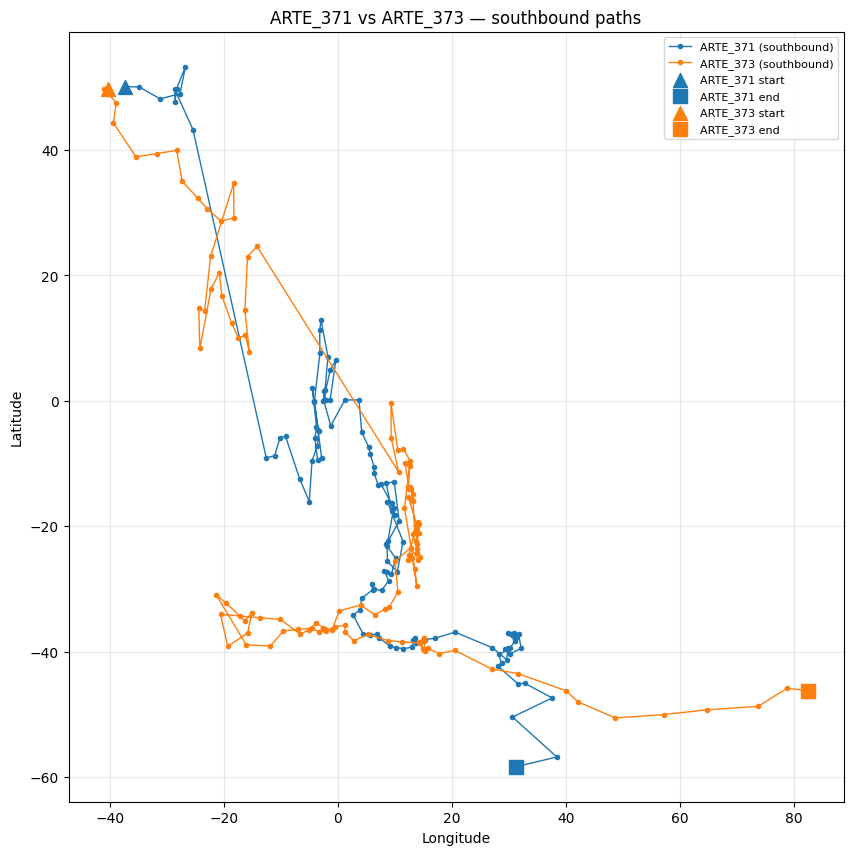

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(south_a['lon'], south_a['lat'], marker='o', markersize=3, linewidth=1,
        label=f'{bird_a_id} (southbound)', color='tab:blue')
ax.plot(south_b['lon'], south_b['lat'], marker='o', markersize=3, linewidth=1,
        label=f'{bird_b_id} (southbound)', color='tab:orange')

if len(south_a):
    ax.scatter(south_a['lon'].iloc[0], south_a['lat'].iloc[0], color='tab:blue', s=100, marker='^', zorder=5, label=f'{bird_a_id} start')
    ax.scatter(south_a['lon'].iloc[-1], south_a['lat'].iloc[-1], color='tab:blue', s=100, marker='s', zorder=5, label=f'{bird_a_id} end')
if len(south_b):
    ax.scatter(south_b['lon'].iloc[0], south_b['lat'].iloc[0], color='tab:orange', s=100, marker='^', zorder=5, label=f'{bird_b_id} start')
    ax.scatter(south_b['lon'].iloc[-1], south_b['lat'].iloc[-1], color='tab:orange', s=100, marker='s', zorder=5, label=f'{bird_b_id} end')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'{bird_a_id} vs {bird_b_id} — southbound paths')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

## What to look for

- **Lines roughly overlap / run close together:** a high average per-step
  DTW distance (like 1573 km) would be a red flag.
- **Lines take visibly different routes** (e.g. one hugs West Africa coast,
  the other crosses toward Brazil): a high average per-step distance is
  expected and confirms the DTW number is realistic.

In [5]:
from bird_dtw.dtw import DTW
from bird_dtw.species.arctic_tern.params import WINDOW_SIZE

path_a = list(zip(south_a["lat"], south_a["lon"]))
path_b = list(zip(south_b["lat"], south_b["lon"]))

dtw = DTW(path_a, path_b, WINDOW_SIZE)
distance, matrix = dtw.dynamic_time_warping()

avg_per_step = distance / max(len(path_a), len(path_b))

print(f"DTW distance: {distance:.2f}")
print(f"Average per-step distance: {avg_per_step:.2f} km")

DTW distance: 196701.90
Average per-step distance: 1573.62 km
